In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

In [2]:
from seaborn import cm

In [3]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [4]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [5]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = "toy_dataset"
dt_name = "german_credit"

cf_method = 'ils'#dice or 'debug'


name_dataset = {"german_credit": "German Credit", 
                "adult": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
cf_results

'counterfactuals/'

In [6]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz


In [7]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit/mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [8]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    utl.plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model random_forest ROC AUC: 0.8
Model random_forest Accuracy: 0.75
Model random_forest F1 Score: 0.72
Model random_forest Balanced Accuracy: 0.62
◑•
•◑

Model mlp ROC AUC: 0.72
Model mlp Accuracy: 0.74
Model mlp F1 Score: 0.73
Model mlp Balanced Accuracy: 0.65
◈○
∙◐

Model xgboost ROC AUC: 0.77
Model xgboost Accuracy: 0.74
Model xgboost F1 Score: 0.73
Model xgboost Balanced Accuracy: 0.65
◈○
∙◐

Model lgbm ROC AUC: 0.78
Model lgbm Accuracy: 0.74
Model lgbm F1 Score: 0.73
Model lgbm Balanced Accuracy: 0.65
◑○
•◐



In [9]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [10]:
np.random.randint(0,7), np.random.rand()*7

(4, 4.410824462525909)

In [11]:

                 
import pickle

#with open("debug/ranking_new_t.pkl", "rb") as f:
#    all_ranking_list_mean, all_ranking_list_std, all_ranking_list_min, all_ranking_list_max, all_probabs,corrects = pickle.load(f)


### The distances took into account

In [12]:
from src.distances import get_distances
metrics = ["l0", "l1", "l2", "inf", "-inf", "sqeuclidean", "mae", "cosine", "correlation", "chebyshev", "minkowski", "canberra", "braycurtis", "hamming", "jaccard", "wasserstein", "spearman", "kendall", "centered_l2", "centered_cosine"]

In [13]:
'''
X = splits['X_test'].values[:10]

x = splits['X_test'].values[0]

print("Distance examples:")
for metric in metrics:
        distances = get_distances(X,x, policy=metric)
        #print(f"{metric} : {[f'{d:.2f}' for d in distances]}")
        plt.plot(distances, label=metric)
plt.legend()
plt.show()
'''

'\nX = splits[\'X_test\'].values[:10]\n\nx = splits[\'X_test\'].values[0]\n\nprint("Distance examples:")\nfor metric in metrics:\n        distances = get_distances(X,x, policy=metric)\n        #print(f"{metric} : {[f\'{d:.2f}\' for d in distances]}")\n        plt.plot(distances, label=metric)\nplt.legend()\nplt.show()\n'

In [14]:
all_stats = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}




In [15]:
all_stats_test = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}


In [16]:
fname = os.path.join(cf_method,dt_name+"_ranking.pkl")
if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
fname_test = os.path.join(cf_method,dt_name+"_ranking_test.pkl")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")


!!!!!! ils/german_credit_ranking.pkl not found
!!!!!! ils/german_credit_ranking_test.pkl not found


In [23]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 200
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(200 elements computed)
random_forest computed? True
(0 elements computed)
	 test? False
(200 elements computed)
mlp computed? True
(0 elements computed)
	 test? False
(200 elements computed)
xgboost computed? True
(0 elements computed)
	 test? False
(200 elements computed)
lgbm computed? True
(0 elements computed)
	 test? False


In [24]:
compute_test = True

In [25]:
all_stats_tmp = all_stats_test if compute_test else all_stats
def select_test (x):return "test" in x if compute_test else ("test" not in x)

In [26]:
select_test("test"), select_test("train")

(True, False)

## Compute the distances 
Counterfactual should be already present

In [27]:



start = time.time()
for jj,k in enumerate(tqdm(models.keys())):
    not_found = 0
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    print("looking into the folder ",result_folder_path)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz") and cf_method in r]
    # remove those that contains "test" in the name
    results = [r for r in results if select_test(r)]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
    # cfs is a dictionary with keys "cfs" as the only key (it's an npz file). The value of "cfs" is a np array of dictionaries. The keys of the dictionaries are:, instace_idx (the index of the instance in the calibration set), original_instance (the original class of the instance), true_class (the true class of the instance)
    print(cfs["cfs"].shape[0])
    if check_res(stats_dict=all_stats_tmp,k=k):
        print("Already computed for model",k,end=" elements:")
        print(len(all_stats_tmp[k]['distances']['l2']['mean']))

        continue
    else:
        print("Computing for model",k)
    probabs = []
    corrects = []
    confs = []
    # cfs = {"cfs":np.arange(200)}
    
    for i in tnrange(cfs["cfs"].shape[0]):
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"]
        # original instance is not anymore the right one sadly... 
        # therefore we get the original instance from the dataset itself by using the "compute_test" flag and the  instance_idx attribute
        original_instance = splits[('X_test' if  compute_test else 'X_calibration')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape(1,-1)
        original_class = cfs["cfs"][i]["true_class"].values
        
        #true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        good_cfs = cfs["cfs"][i]["counterfactuals"].values#[:,:-1]
        #good_cfs = good_cfs[true_cf != pred]
        true_cf = np.ones(len(good_cfs))#true_cf[true_cf != pred]
        if len (good_cfs) > 0:
            mean_confidences_cfs = models[k].predict_proba(good_cfs).mean(axis=0)
        else:
            mean_confidences_cfs = np.array([np.nan,np.nan])
        for metric in metrics:
            if len(true_cf) == 0:
                distancies = np.array([np.inf])
                print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
                not_found+=1
            else:
                assert (true_cf-true_cf.mean() == 0).all(), "The counterfactuals are not aligned with the target"+str(true_cf)
                #distancies = np.linalg.norm(good_cfs - cfs["cfs"][i]["original_instance"].values,axis=1)
                distancies = get_distances(good_cfs, cfs["cfs"][i]["original_instance"].values,
                                        policy=metric)
            
            all_stats_tmp[k]['distances'][metric]['min'].append(distancies.min(axis=0))
            all_stats_tmp[k]['distances'][metric]['max'].append(distancies.max(axis=0))
            all_stats_tmp[k]['distances'][metric]['mean'].append(distancies.mean(axis=0))
            all_stats_tmp[k]['distances'][metric]['std'].append(distancies.std(axis=0))
            
        probabs.append(pred_prob)
        corrects.append(correct)
        confs.append(mean_confidences_cfs)
        # print(distancies)
        #if i / 4 < 1:
        #   sns.kdeplot(distancies,cumulative=False,label=str(i)+" "+str(len(distancies))+ " counterfactuals "+k,ax=axs[i])
    all_stats_tmp[k]['probabs'] = probabs
    all_stats_tmp[k]['corrects'] = corrects
    all_stats_tmp[k]['mean_conf'] = confs
    print("For the model ",k,"not found",not_found,"counterfactuals")


  0%|          | 0/4 [00:00<?, ?it/s]

looking into the folder  counterfactuals/random_forest/german_credit
I found 1 files
for model random_forest using file cf_results_ils_latent_test_20250210_212054.npz
checking cf_results_ils_latent_test_20250210_212054.npz
250
(0 elements computed)
Computing for model random_forest


  0%|          | 0/250 [00:00<?, ?it/s]

NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 27
NOT FOUND COUNTERFACTUALS FOR SAMPLE 116
NOT FOUND COUNTERFACTUALS FOR SAMPLE 116
NOT FOUND COUNTERFACTUALS FOR SAMPLE 116
NOT FOUND COUNTERFACTUALS FOR SAMPLE 116
NOT FOUND COUNTERFACTUALS FOR SAMPLE

  0%|          | 0/250 [00:00<?, ?it/s]

For the model  mlp not found 0 counterfactuals
looking into the folder  counterfactuals/xgboost/german_credit
I found 1 files
for model xgboost using file cf_results_ils_latent_test_20250211_003152.npz
checking cf_results_ils_latent_test_20250211_003152.npz
250
(0 elements computed)
Computing for model xgboost


  0%|          | 0/250 [00:00<?, ?it/s]

For the model  xgboost not found 0 counterfactuals
looking into the folder  counterfactuals/lgbm/german_credit
I found 1 files
for model lgbm using file cf_results_ils_latent_test_20250211_030422.npz
checking cf_results_ils_latent_test_20250211_030422.npz
250
(0 elements computed)
Computing for model lgbm


  0%|          | 0/250 [00:00<?, ?it/s]

For the model  lgbm not found 0 counterfactuals


In [28]:
fname,fname_test

('ils/german_credit_ranking.pkl', 'ils/german_credit_ranking_test.pkl')

## Save files for the distances
if not already present

In [29]:
if compute_test:
    all_stats_test = all_stats_tmp
else:
    all_stats = all_stats_tmp
compute_test

True

0.755
0.752
True True
0.73
0.744
True True
0.705
0.744
True True
0.76
0.744
True True


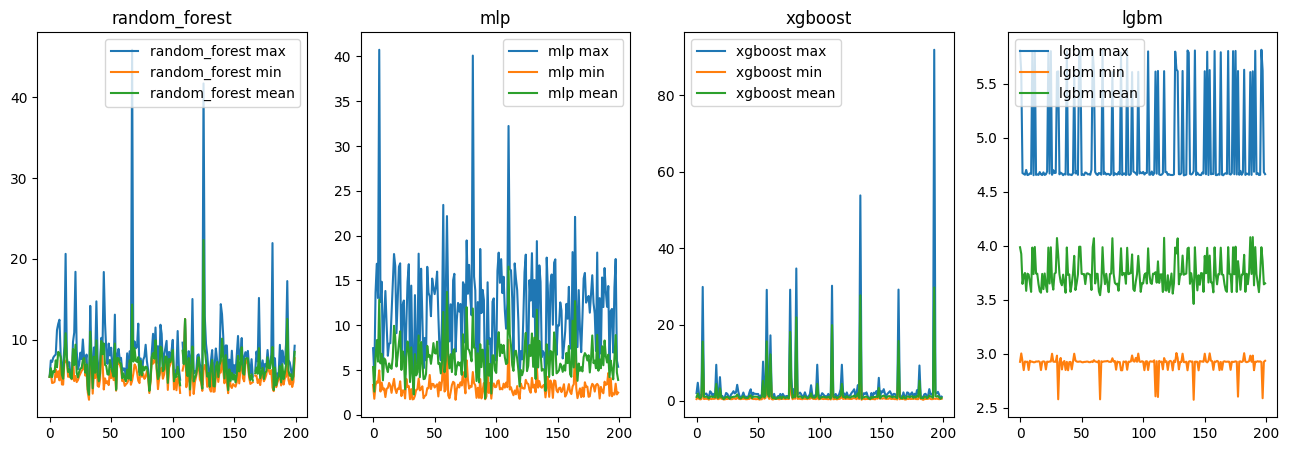

In [30]:
# to check plot the distances of the l2 metric for all the models
# use four subplots
fig, axs = plt.subplots(1,4,figsize=(16,5))
axs = axs.flatten()
for jj,k in enumerate(models.keys()):
    axs[jj].plot(all_stats[k]['distances']['l2']['max'],label=k+" max")
    axs[jj].plot(all_stats[k]['distances']['l2']['min'],label=k+" min")
    axs[jj].plot(all_stats[k]['distances']['l2']['mean'],label=k+" mean")
    # check the correct list


    print(np.array(all_stats[k]['corrects']).sum()/len(all_stats[k]['corrects']))
    print(np.array(all_stats_test[k]['corrects']).sum()/len(all_stats_test[k]['corrects']))
    print(0.0==0,1.0==1)

    # set the legend and the title
    axs[jj].legend()
    axs[jj].set_title(k)
    

In [44]:
# If I did an error, I have to remove the the whole list of distances for the models in the all_stats dictionary
# I will "re initialize" the list of distances for the models
'''
for k in ["mlp","lgbm","xgboost"]:
    all_stats[k]['distances'] = {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per samplea
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        }
'''

'\nfor k in ["mlp","lgbm","xgboost"]:\n    all_stats[k][\'distances\'] = {\n            metric: {\n                \'min\': [],   # One value per sample\n                \'max\': [],   # One value per samplea\n                \'mean\': [],  # One value per sample, equal to min or max if only one value\n                \'std\': [],   # One value per sample\n            } for metric in metrics\n        }\n'

In [31]:
# check how many distancies are computed, i fear that I have confused the test and calibration set
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(200 elements computed)
random_forest computed? True
(250 elements computed)
	 test? True
(200 elements computed)
mlp computed? True
(250 elements computed)
	 test? True
(200 elements computed)
xgboost computed? True
(250 elements computed)
	 test? True
(200 elements computed)
lgbm computed? True
(250 elements computed)
	 test? True


In [32]:
fname

'ils/german_credit_ranking.pkl'

In [33]:

if not utl.check_file_exists(fname):
    with open(fname, "wb") as f:
        pickle.dump(all_stats, f)
        print("dumped",fname)
else:
    print("File already exists",fname)

dumped ils/german_credit_ranking.pkl


In [34]:
fname_test

'ils/german_credit_ranking_test.pkl'

In [35]:

if not utl.check_file_exists(fname_test):
    with open(fname_test, "wb") as f:
        pickle.dump(all_stats_test, f)
        print("dumped",fname_test)
else:
    print("File already exists",fname_test)


dumped ils/german_credit_ranking_test.pkl
